In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os

sys.path.append('..')
sys.path.append(os.path.abspath(os.path.join('..', 'magnet-pinn')))
sys.path.append(os.path.abspath(os.path.join('..', 'neuraloperator')))

In [5]:
from torch.utils.data import DataLoader

from magnet_pinn.data.transforms import Compose, Crop, CoilEnumeratorPhaseShift
from magnet_pinn.data.grid import MagnetGridIterator

TRAIN_DIR = "../data/processed/batch_17/grid_voxel_size_4_data_type_float32"
VAL_DIR = "../data/processed/batch_17/grid_voxel_size_4_data_type_float32"

augmentation = Compose(
    [
        Crop(crop_size=(100, 100, 100)),
        CoilEnumeratorPhaseShift(num_coils=8)
    ]
)

val_set = MagnetGridIterator(VAL_DIR, transforms=augmentation, num_samples=8)
val_loader = iter(DataLoader(val_set, batch_size=1))

In [ ]:
from mrifield.models import UNet3D
from neuralop.models import FNO, UNO
from mrifield.train.lit_mrifield import LitMRIField
from magnet_pinn.utils import StandardNormalizer, StandardNormalizerSqrt

CKPT = "tfno/tfno_2X/l9mn56g5_15.ckpt"
#CKPT = "unet/unet_32M_90F_stdsqrt/ej92qasc_15.ckpt"

#model = UNet3D(in_channels=5, out_channels=12, f_maps=90, num_groups=9)
model = FNO(n_modes=(16, 16, 16), in_channels=5, out_channels=12, hidden_channels=59, positional_embedding=None, factorization='tucker', rank=0.5)
#model = UNO(in_channels=5, out_channels=12, hidden_channels=16, uno_out_channels=[32,64,64,32], uno_n_modes=[[16,16,16],[16,16,16],[16,16,16],[16,16,16]], uno_scalings=[[1,1,1],[0.5,0.5,0.5],[1,1,1],[2,2,2]], channel_mlp_skip='linear')

train_input_normalizer = StandardNormalizer.load_from_json(f"{TRAIN_DIR}/normalization/std/input_normalization.json")
train_target_normalizer = StandardNormalizerSqrt.load_from_json(f"{TRAIN_DIR}/normalization/std/target_normalization.json")

trained_model = LitMRIField.load_from_checkpoint(
    CKPT,
    model=model,
    input_normalizer=train_input_normalizer,
    target_normalizer=train_target_normalizer,
    #val_input_normalizer=train_input_normalizer,
    #val_target_normalizer=train_target_normalizer
)

trained_model.eval()

In [7]:
sample = next(iter(val_loader))

In [6]:
import torch
import math
import einops

curl_filter = torch.zeros((3,3,3,3,3), dtype=torch.float32)
dx = 0.004

# dVz / dy - dVy / dz
curl_filter[0,2,1,0,1] = -1 / (2 * dx) # dy
curl_filter[0,2,1,2,1] = 1 / (2 * dx)  # dy
curl_filter[0,1,1,1,0] = 1 / (2 * dx)  # dz
curl_filter[0,1,1,1,2] = -1 / (2 * dx) # dz

# dVx / dz - dVz / dx
curl_filter[1,0,1,1,0] = -1 / (2 * dx) # dz
curl_filter[1,0,1,1,2] = 1 / (2 * dx)  # dz
curl_filter[1,2,0,1,1] = 1 / (2 * dx)  # dx
curl_filter[1,2,2,1,1] = -1 / (2 * dx) # dx

# dVy / dx - dVx / dy
curl_filter[2,1,0,1,1] = -1 / (2 * dx) # dx
curl_filter[2,1,2,1,1] = 1 / (2 * dx)  # dx
curl_filter[2,0,1,0,1] = 1 / (2 * dx)  # dy
curl_filter[2,0,1,2,1] = -1 / (2 * dx) # dy

inputs = sample['input']
coils = sample['coils']
subject = sample['subject']
target = einops.rearrange(sample['field'], 'b he reim xyz ... -> b (he reim xyz) ...')

x = train_input_normalizer(torch.cat([inputs, coils], dim=1))
with torch.no_grad():
    pred = train_target_normalizer.inverse(trained_model(x))

pred_e_re = pred[:,0:3,:,:,:]
pred_e_im = pred[:,3:6,:,:,:]
pred_h_re = pred[:,6:9,:,:,:]
pred_h_im = pred[:,9:12,:,:,:]
pred_h_complex = pred_h_re + 1j * pred_h_im

target_e_re = target[:,0:3,:,:,:]
target_e_im = target[:,3:6,:,:,:]
target_h_re = target[:,6:9,:,:,:]
target_h_im = target[:,9:12,:,:,:]
target_h_complex = target_h_re + 1j * target_h_im

curl_pred_e_re = torch.nn.functional.conv3d(pred_e_re, curl_filter, padding=1)
curl_pred_e_im = torch.nn.functional.conv3d(pred_e_im, curl_filter, padding=1)
curl_target_e_re = torch.nn.functional.conv3d(target_e_re, curl_filter, padding=1)
curl_target_e_im = torch.nn.functional.conv3d(target_e_im, curl_filter, padding=1)

curl_pred = curl_pred_e_re + 1j * curl_pred_e_im
curl_target = curl_target_e_re + 1j * curl_target_e_im

faradays_pred = curl_pred + 1j * 2 * math.pi * 297.2e6 * 1.256637061e-6 * pred_h_complex
faradays_target = curl_target + 1j * 2 * math.pi * 297.2e6 * 1.256637061e-6 * target_h_complex

In [ ]:
from magnet_pinn.losses.utils import DiffFilterFactory
from magnet_pinn.losses.physics import DivergenceLoss, FaradaysLoss

class ObjectMaskPadding:
    def __init__(self, padding: int = 1):
        self.padding = padding
        self.padding_filter = torch.ones([1,1] + [self.padding*2 + 1]*3, dtype=torch.float32)

    def __call__(self, input_shape_mask: torch.Tensor) -> torch.Tensor:
        check_border = torch.nn.functional.conv3d(input_shape_mask.type(torch.float32), self.padding_filter, padding=self.padding)
        return check_border == torch.sum(self.padding_filter)

pad = ObjectMaskPadding()
zero = torch.zeros((1, 100, 100, 100))
pad(zero)

div_filter = DiffFilterFactory().divergence()

div_pred_re = torch.nn.functional.conv3d(pred[:,6:9,:,:,:], div_filter, padding=1)
div_pred_im = torch.nn.functional.conv3d(pred[:,9:12,:,:,:], div_filter, padding=1)
div_target_re = torch.nn.functional.conv3d(target[:,6:9,:,:,:], div_filter, padding=1)
div_target_im = torch.nn.functional.conv3d(target[:,9:12,:,:,:], div_filter, padding=1)

div_target = div_target_re + 1j * div_target_im

div = DivergenceLoss()
far = FaradaysLoss()

#div_target = torch.sqrt(div(target, target, subject))
#div_pred = div(pred, target, subject)
#print(div_target)
#print(div_pred)

#far_target = torch.sqrt(far(target, target, pad(subject)))
#far_pred = far(pred, target, pad(subject))
#print(far_target)
#print(far_pred)

In [ ]:
import torch
import matplotlib.pyplot as plt

gt = torch.sqrt(torch.mean(faradays_target.abs(), dim=1))
pr = torch.sqrt(torch.mean(faradays_pred.abs(), dim=1))

print(f"MAE FAR Subject (GT): {torch.mean(gt[pad(subject)])}")
print(f"MAE FAR Subject (PR): {torch.mean(pr[pad(subject)])}")

gt[~pad(subject)] = 1e-6
pr[~pad(subject)] = 1e-6
rs = (pr - gt)

# Plot multiple slices of a single sample
_, axes = plt.subplots(6, 2, figsize=(10, 30))
titles = ['Ground truth', 'Prediction', 'Residual', 'Ground truth - H', 'Prediction - H', 'Residual - H']

min = torch.min(gt.min(), pr.min())
max = torch.max(gt.max(), pr.max())

for column, title in zip(axes[0], titles):
    column.set_title(title, fontsize=16)

for row in range(6):
    slice = 20 + row * 10

    gt_e = axes[row, 0].imshow(gt[0, :, :, slice], cmap='viridis')
    pr_e = axes[row, 1].imshow(pr[0, :, :, slice], cmap='viridis')
    plt.colorbar(gt_e)
    plt.colorbar(pr_e)

plt.show()

torch.Size([1, 1, 100, 100, 100])
MAE FAR Subject (GT): 2.104663610458374
MAE FAR Subject (PR): 6.548214435577393


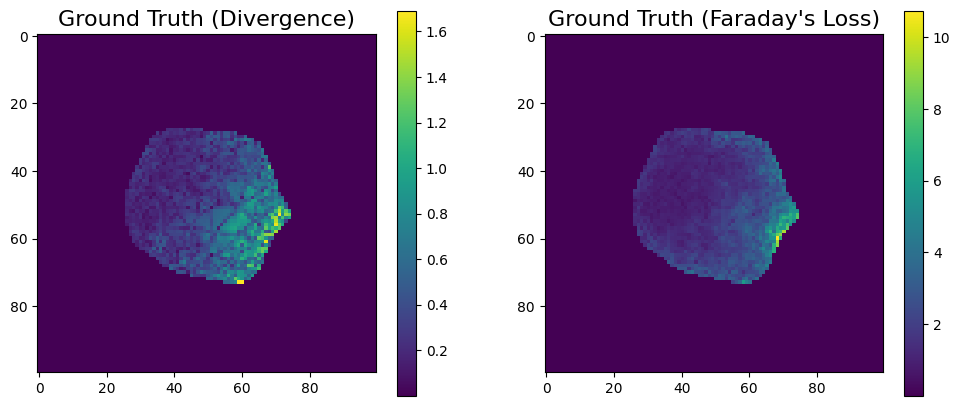

In [ ]:
import torch
import matplotlib.pyplot as plt

gt_div = torch.sqrt(torch.mean(div_target.abs(), dim=1))
gt_far = torch.sqrt(torch.mean(faradays_target.abs(), dim=1))

print(f"MAE FAR Subject (GT): {torch.mean(gt[pad(subject)])}")
print(f"MAE FAR Subject (PR): {torch.mean(pr[pad(subject)])}")

gt_div[~pad(subject)] = 1e-6
gt_far[~pad(subject)] = 1e-6
rs = (pr - gt)

# Plot multiple slices of a single sample
_, axes = plt.subplots(1, 2, figsize=(12, 5))
titles = ['Ground Truth (Divergence)', 'Ground Truth (Faraday\'s Loss)', 'Residual', 'Ground truth - H', 'Prediction - H', 'Residual - H']

min = torch.min(gt.min(), pr.min())
max = torch.max(gt.max(), pr.max())

for column, title in zip(axes, titles):
    column.set_title(title, fontsize=16)

slice = 50

gt_e = axes[0].imshow(gt_div[0, :, :, slice], cmap='viridis')
pr_e = axes[1].imshow(gt_far[0, :, :, slice], cmap='viridis')
plt.colorbar(gt_e)
plt.colorbar(pr_e)

plt.show()

[<Axes: > <Axes: > <Axes: >]


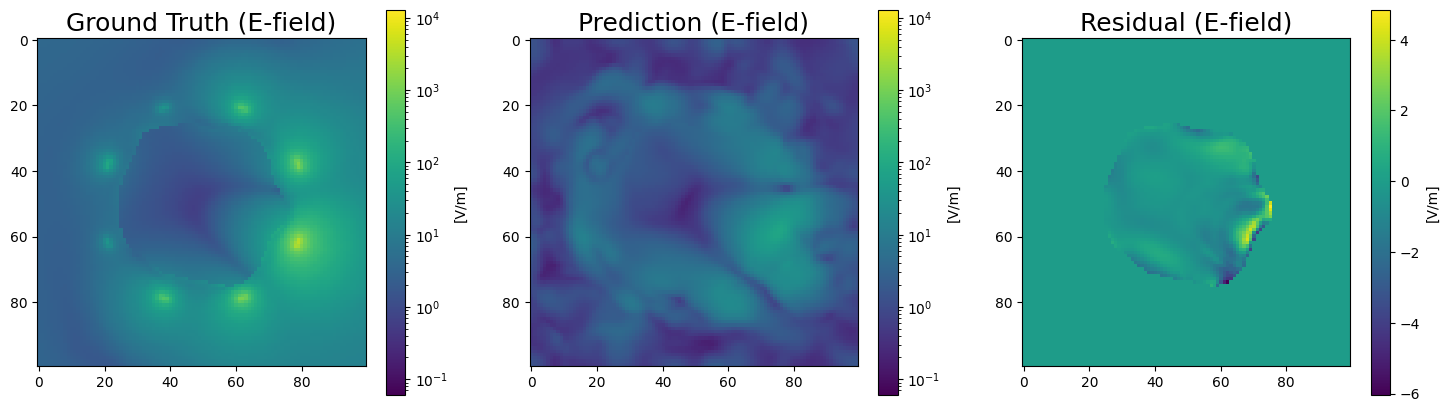

In [ ]:
import torch
import einops
import matplotlib.pyplot as plt

subject = sample['subject']

# Ground truth
gt_re = sample['field'][0, :, 0]
gt_im = sample['field'][0, :, 1]

gt = torch.norm(torch.complex(gt_re, gt_im), dim=1)

# Prediction
inputs = sample['input']
coils = sample['coils']

x = train_input_normalizer(torch.cat([inputs, coils], dim=1))
with torch.no_grad():
    pred = train_target_normalizer.inverse(trained_model(x))
    pred = einops.rearrange(pred, 'b (he reim xyz) ... -> b he reim xyz ...', he=2, reim=2, xyz=3)

pr_re = pred[0, :, 0]
pr_im = pred[0, :, 1]

pr = torch.norm(torch.complex(pr_re, pr_im), dim=1)

# Residuals (Subject)
rs = (pr - gt) * subject

# Plot multiple slices of a single sample
_, axes = plt.subplots(1, 3, figsize=(18, 5))

titles = ['Ground Truth (E-field)', 'Prediction (E-field)', 'Residuals (E-field)']

e_vmin = min(gt[0].min(), pr[0].min())
e_vmax = max(gt[0].max(), pr[0].max())

rs_e_vmin = rs[0].min()
rs_e_vmax = rs[0].max()

for column, title in zip(axes, titles):
    column.set_title(title, fontsize=18)

slice = 50

gt_e = axes[0].imshow(gt[0, :, :, slice], cmap='viridis', norm='log', vmin = e_vmin, vmax = e_vmax)
pr_e = axes[1].imshow(pr[0, :, :, slice], cmap='viridis', norm='log', vmin = e_vmin, vmax = e_vmax)
rs_e = axes[2].imshow(rs[0, :, :, slice], cmap='viridis')

plt.colorbar(gt_e, label='[V/m]')
plt.colorbar(pr_e, label='[V/m]')
plt.colorbar(rs_e, label='[V/m]')

plt.show()

In [86]:
from captum.attr import IntegratedGradients

ig = IntegratedGradients(model)
attr = ig.attribute(torch.cat((sample['input'], sample['coils']), dim=1), target=(0,50,50,50), n_steps=1)

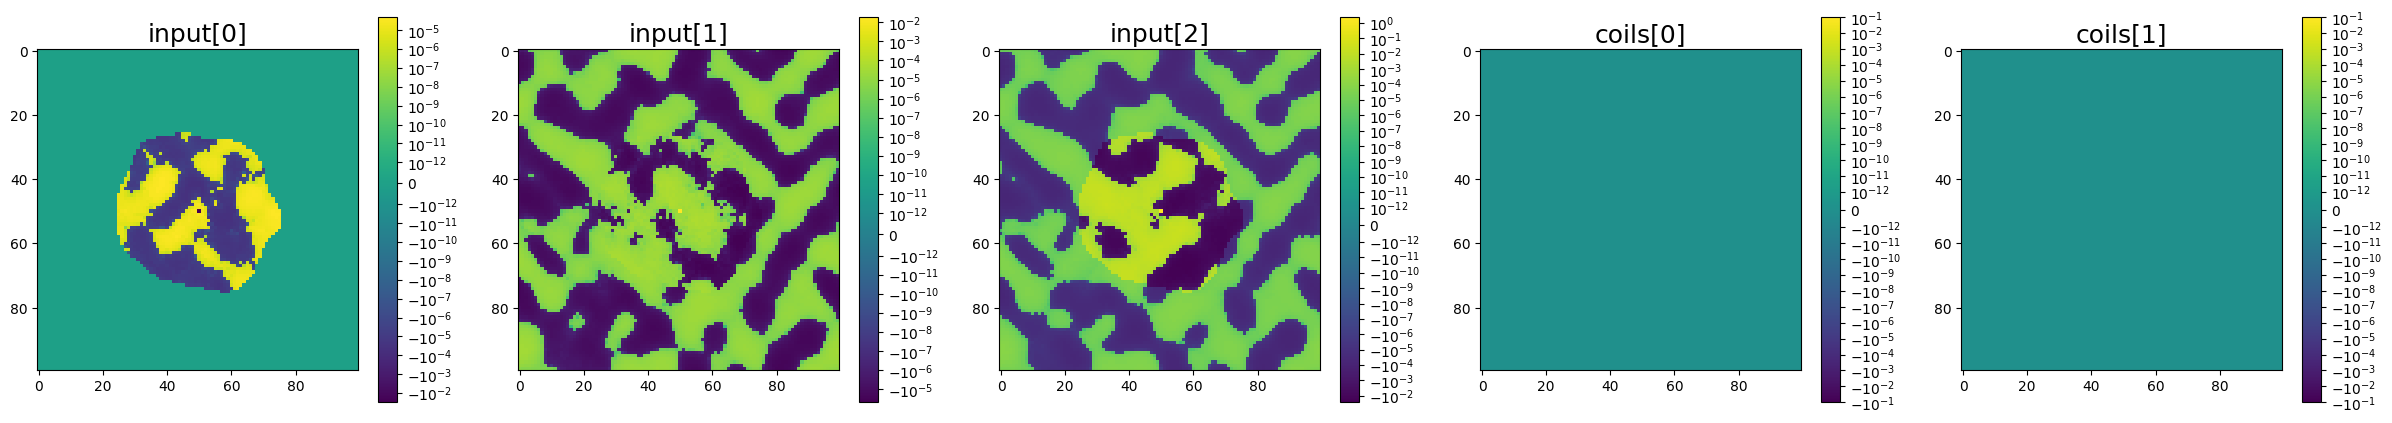

In [87]:
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm

titles = ['input[0]', 'input[1]', 'input[2]', 'coils[0]', 'coils[1]']

_, axes = plt.subplots(1, 5, figsize=(30, 5))

for column, title in zip(axes, titles):
    column.set_title(title, fontsize=18)

slice = 50

input0 = axes[0].imshow(attr[0, 0, :, :, slice], cmap='viridis', norm=SymLogNorm(linthresh=1e-12))
input1 = axes[1].imshow(attr[0, 1, :, :, slice], cmap='viridis', norm=SymLogNorm(linthresh=1e-12))
input2 = axes[2].imshow(attr[0, 2, :, :, slice], cmap='viridis', norm=SymLogNorm(linthresh=1e-12))
coils0 = axes[3].imshow(attr[0, 3, :, :, slice], cmap='viridis', norm=SymLogNorm(linthresh=1e-12))
coils1 = axes[4].imshow(attr[0, 4, :, :, slice], cmap='viridis', norm=SymLogNorm(linthresh=1e-12))

plt.colorbar(input0)
plt.colorbar(input1)
plt.colorbar(input2)
plt.colorbar(coils0)
plt.colorbar(coils1)

plt.show()

In [85]:
attr_unet = attr

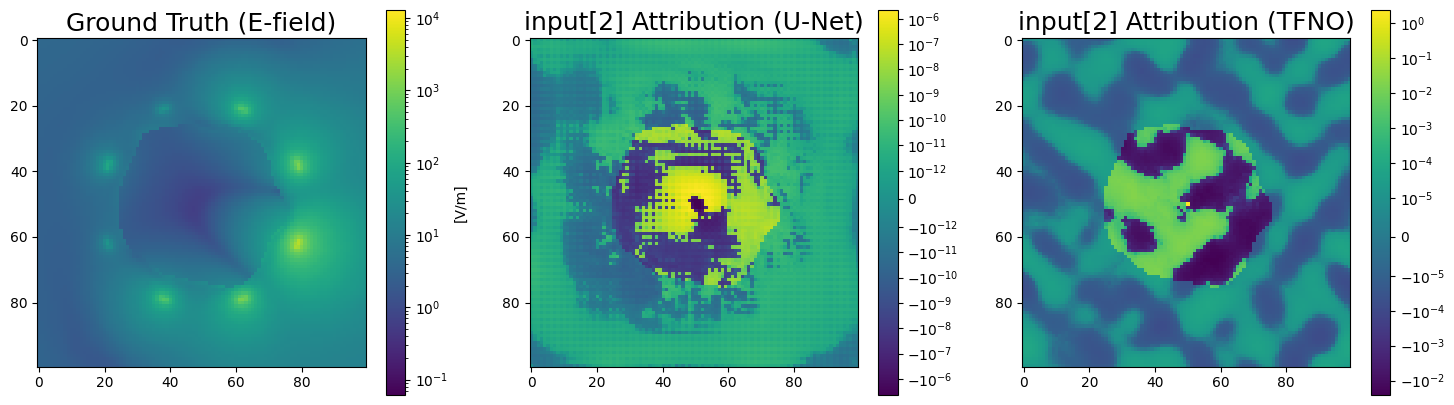

In [88]:
import torch
import einops
import matplotlib.pyplot as plt

subject = sample['subject']

# Ground truth
gt_re = sample['field'][0, :, 0]
gt_im = sample['field'][0, :, 1]

gt = torch.norm(torch.complex(gt_re, gt_im), dim=1)

# Plot multiple slices of a single sample
_, axes = plt.subplots(1, 3, figsize=(18, 5))

titles = ['Ground Truth (E-field)', 'input[2] Attribution (U-Net)', 'input[2] Attribution (TFNO)']

e_vmin = min(gt[0].min(), pr[0].min())
e_vmax = max(gt[0].max(), pr[0].max())

for column, title in zip(axes, titles):
    column.set_title(title, fontsize=18)

slice = 50

gt_e = axes[0].imshow(gt[0, :, :, slice], cmap='viridis', norm='log', vmin = e_vmin, vmax = e_vmax)
input2_unet = axes[1].imshow(attr_unet[0, 2, :, :, slice], cmap='viridis', norm=SymLogNorm(linthresh=1e-12))
input2_tfno = axes[2].imshow(attr[0, 2, :, :, slice], cmap='viridis', norm=SymLogNorm(linthresh=1e-5))

plt.colorbar(gt_e, label='[V/m]')
plt.colorbar(input2_unet)
plt.colorbar(input2_tfno)

plt.show()